In [1]:
 # 1. Incarcarea setului de date

from sklearn.datasets import load_wine
wine = load_wine()


In [2]:
 # 2. Afisarea primelor 5 randuri

wine = load_wine(as_frame=True)
wine.frame.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
 # 3.Caracteristicile

print(wine.feature_names)


['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


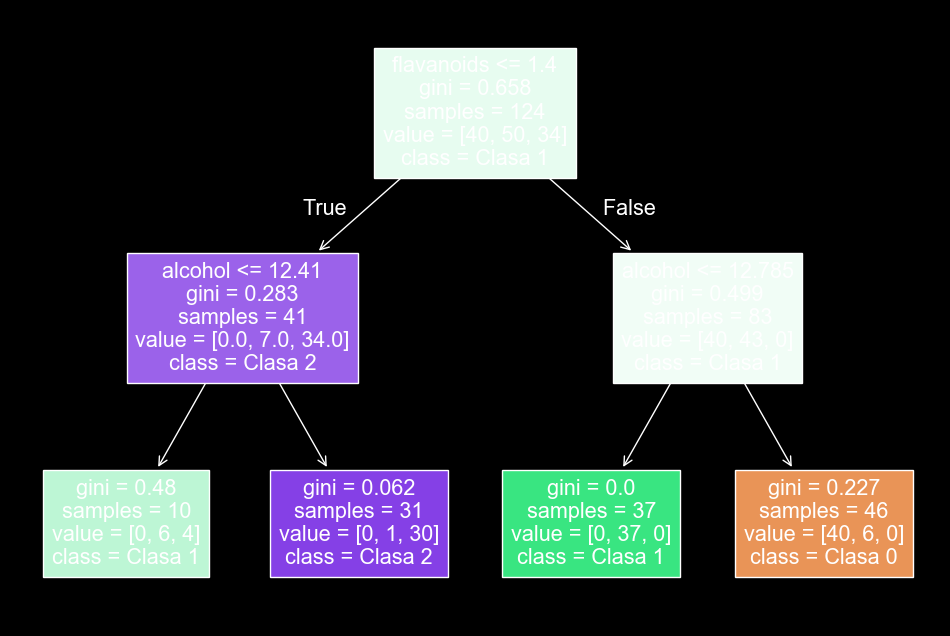

In [5]:
 # 4. Antrenarea arborelui de decizie
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X = wine.frame[['alcohol', 'flavanoids']]
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,random_state=42)

model = DecisionTreeClassifier(max_depth=2,random_state=42)

model.fit(X_train, y_train)

plt.figure(figsize=(12,8))

plot_tree(model,feature_names=['alcohol', 'flavanoids'],class_names=['Clasa 0', 'Clasa 1', 'Clasa 2'],filled=True)

plt.show()

In [6]:
 # 5.Antrenare arbore complet

from sklearn.metrics import accuracy_score

full_model = DecisionTreeClassifier(max_depth=None,random_state=42)

full_model.fit(X_train, y_train)

y_pred = full_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Acuratete pe setul de testare: {accuracy:.4f}")

Acuratete pe setul de testare: 0.8889


In [7]:
 # 6. Antrenarea unui model pe toate cele 13 caracteristici

X_all = wine.data
y_all = wine.target

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all,y_all,test_size=0.3,random_state=42)
model_all = DecisionTreeClassifier(random_state=42)
model_all.fit(X_train_all, y_train_all)

importances = model_all.feature_importances_

for feature, importance in zip(wine.feature_names, importances):
    print(f"{feature}: {importance:.4f}")

alcohol: 0.0210
malic_acid: 0.0000
ash: 0.0240
alcalinity_of_ash: 0.0000
magnesium: 0.0000
total_phenols: 0.0000
flavanoids: 0.4147
nonflavanoid_phenols: 0.0000
proanthocyanins: 0.0000
color_intensity: 0.4115
hue: 0.0000
od280/od315_of_diluted_wines: 0.0000
proline: 0.1289
